<a href="https://colab.research.google.com/github/Riz2693/Eksperimen-TensorFlow/blob/main/TensorFlow%20Model%20Creation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Muhammad Faris Akbar**
Catatan Pembelaran TensorFlow Lanjutan

# **Section 1**
# **Inisialisasi Model TensorFlow**
1. Sequential API
2. Functional API
3. Subclassing

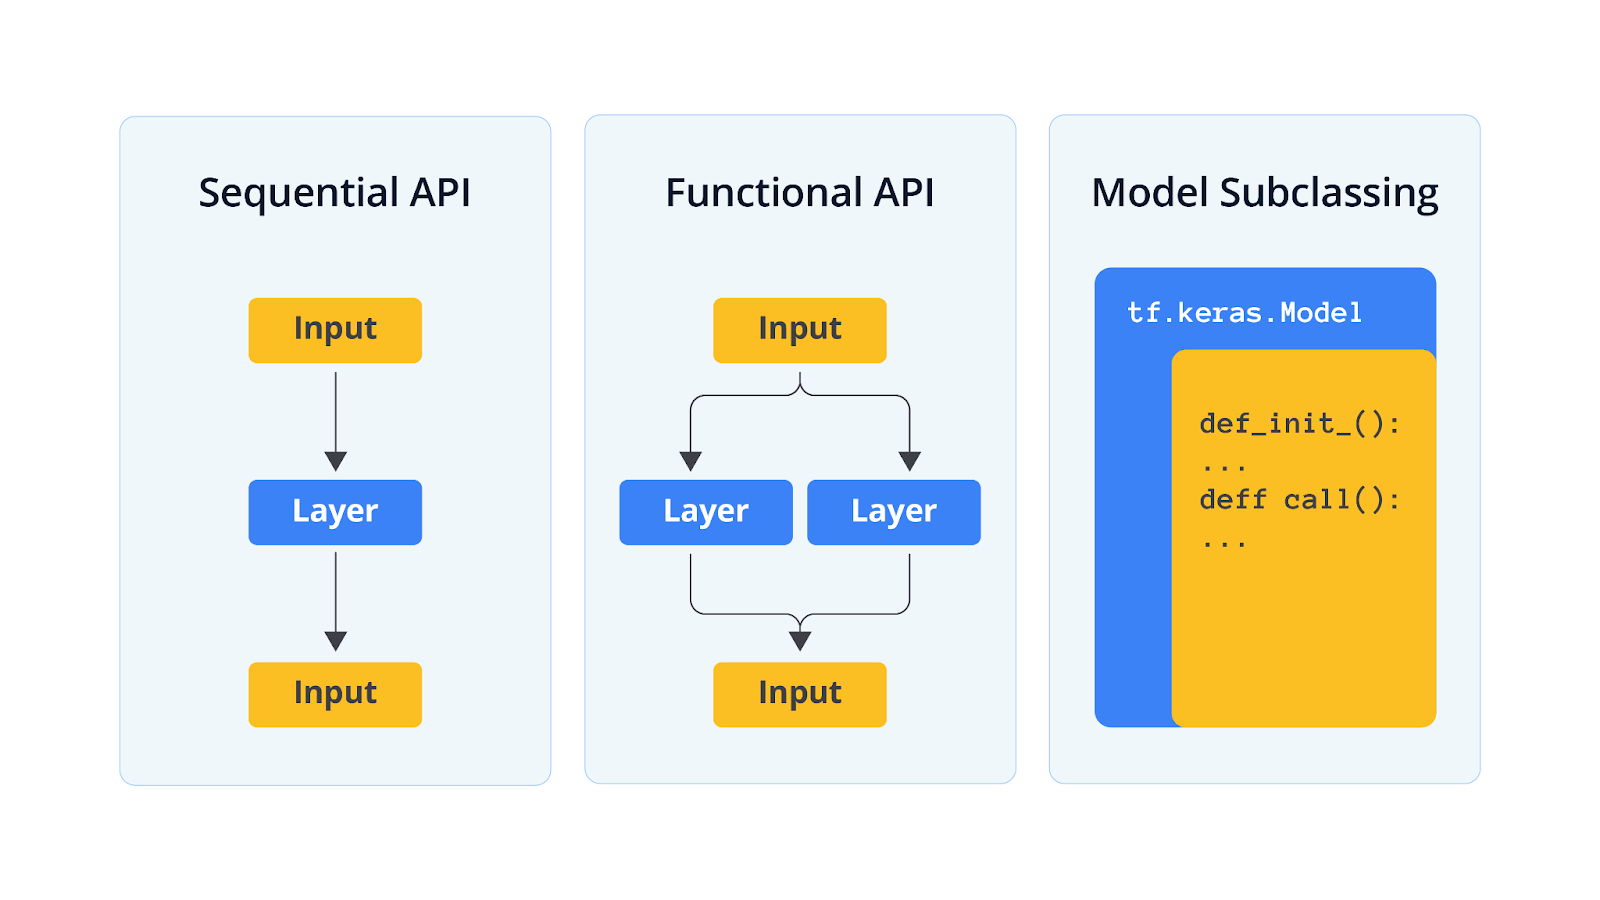

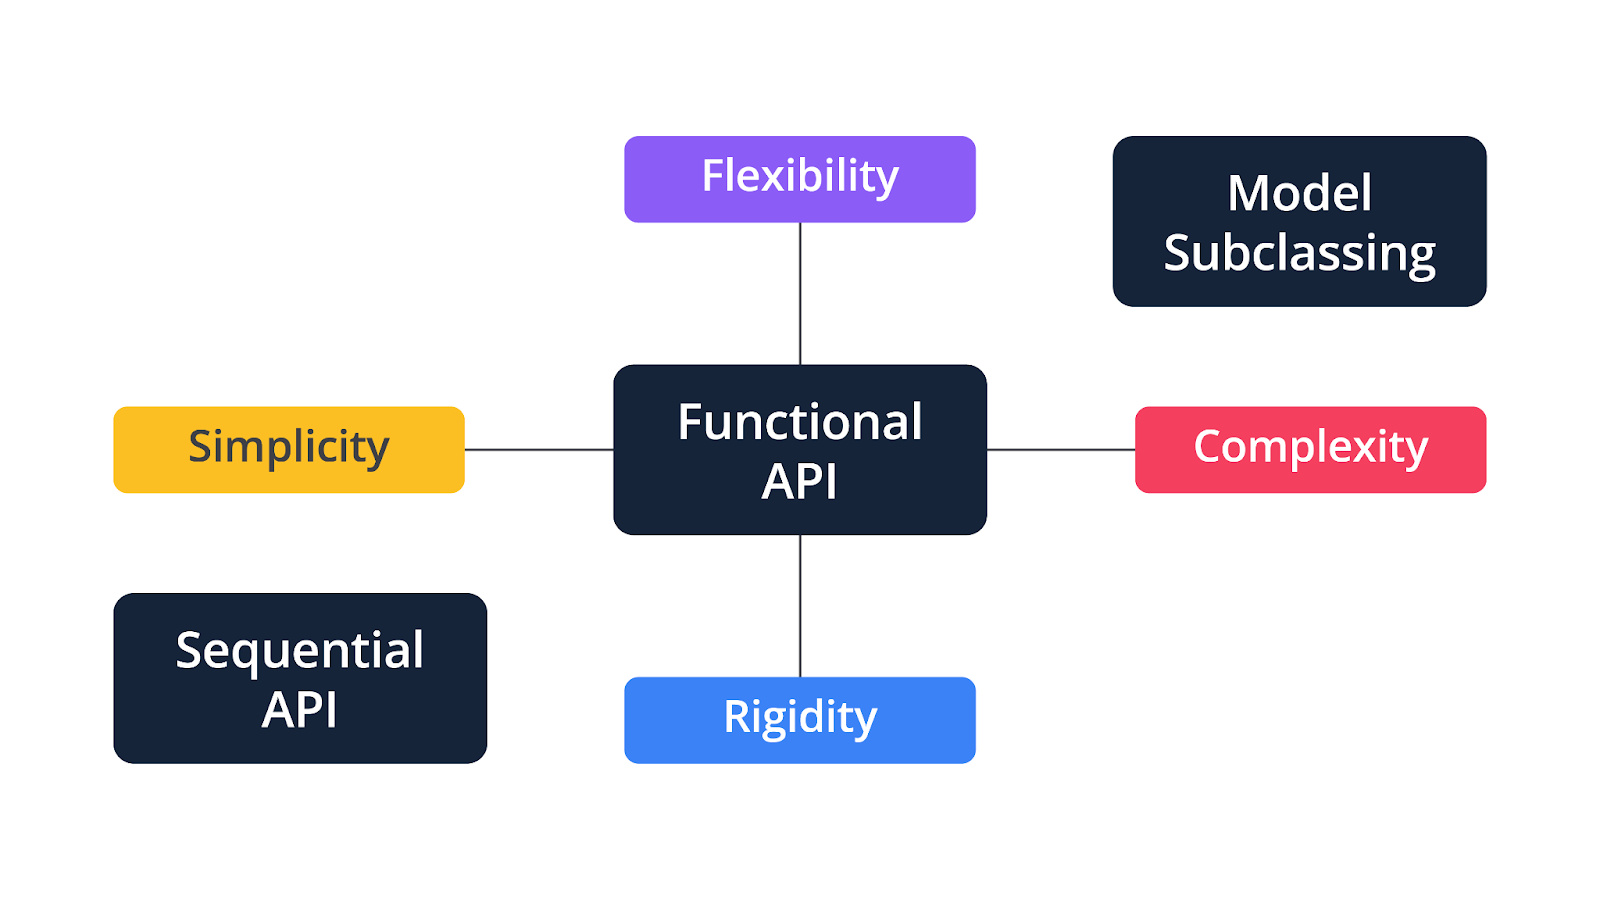

# **Kelebihan dan kekurangan masing-masing pendekatan:**



## **Sequential API**
**Kelebihan**
1. Mudah diimplementasikan
2. Simple dan ringan

**Kekurangan**
1. Keterbatasan pada pengaturan model
2. Hanya bisa mempelajari 1 arah saja (feed forward learning)


## **Contoh Model dan Impementasi nya**

In [5]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [8]:
model = Sequential([
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
    ])

## **Functional API**
**Kelebihan**
1. Mudah dikustomisasi
2. Mendukung multi input dan output
3. Fleksibilitas model
4. Mendukung fine tuning dan transfer learning yang beragam
5. Mendukung pembelajaran 2 arah (feed forward dan backpropagation learning) (Bidirectional)

**Kekurangan**
1. Lebih rumit dibandingkan sequential api
2. Keterbatasan dalam menambahkan perilaku custom
3. Kurang cocok untuk arsitektur model yang dinamis

In [15]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

In [16]:
input = Input(shape=(32,))
x = Dense(128, activation='relu')(input)
x = Dense(64, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

In [17]:
model = Model(inputs=input, outputs=output)

## **Subclassing**
**Kelebihan**
1. Flesibilitas penuh (custom model)
2. Mendukung model dinamis
4. Mendukung customisasi model fine tuning dan transfer learning yang lebih beragam
5. Sama seperti functional api mendukung pembelajaran 2 arah (feed forward dan backpropagation learning) (Bidirectional)

**Kekurangan**
1. Lebih rumit dibandingkan sequential api maupun functional api


In [ ]:
class MyDenseLayer(Layer):
    def __init__(self, units=32, activation=None):
        super().__init__()
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(
            name="kernel",
            shape=(input_shape[-1], self.units),
            initializer=tf.random_normal_initializer(),
            trainable=True
        )
        self.b = self.add_weight(
            name="bias",
            shape=(self.units,),
            initializer=tf.zeros_initializer(),
            trainable=True
        )

    def call(self, inputs):
        return self.activation(tf.matmul(inputs, self.w) + self.b)

# **Section 2**
# **Contoh penggunaan subclassing lanjutan**

## **Model residual network (ResNet)**

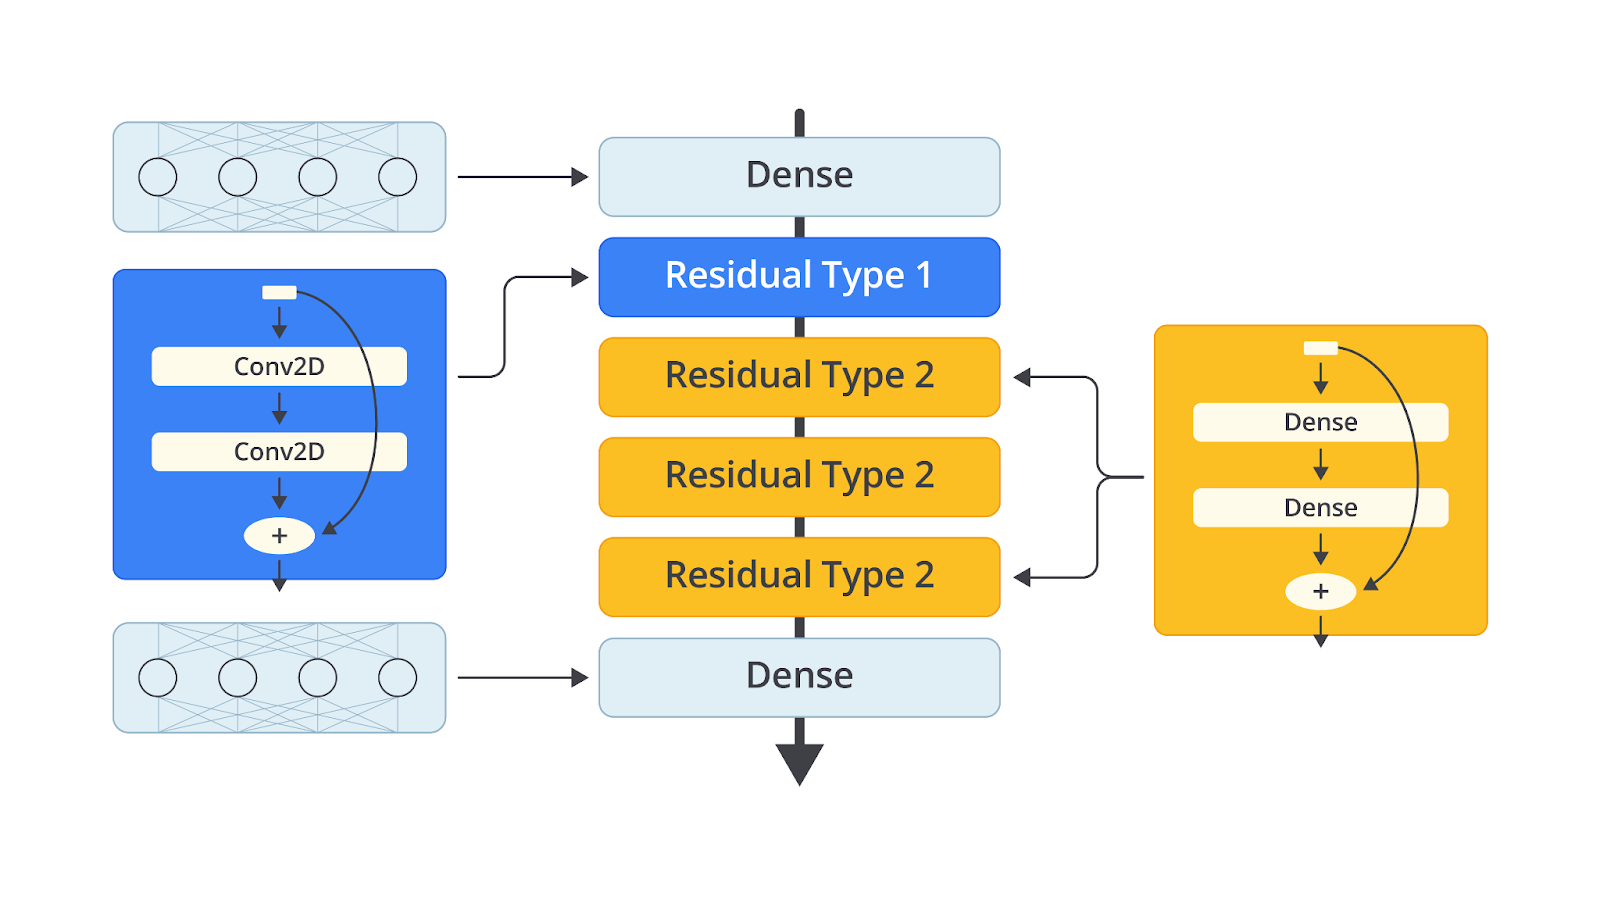

In [ ]:
class ResidualType1(Layer):
  def __init__(self, layers, filters, **kwargs):
    super().__init__(**kwargs)
    self.hidden = [Conv2D(filters, (3, 3), activation='relu') for _ in range(layers)]

  def call(self, inputs):
    x = inputs
    for layer in self.hidden:
      x = layer(x)
    return inputs + x

In [ ]:
class ResidualType2(Layer):
  def __init__(self, layers, units, **kwargs):
    super().__init__(**kwargs)
    self.hidden = [Dense(units, activation='relu') for _ in range(layers)]

  def call(self, inputs):
    x = inputs
    for layer in self.hidden:
      x = layer(x)
    return inputs + x

In [ ]:
class MyResidual(Model):
  def __init__(self, **kwargs):
    self.hidden = Dense(30, activation='relu')
    self.block1 = ResidualType1(2, 32)
    self.block2 = ResidualType2(2, 64)
    self.out = Dense(1)

  def call(self, inputs):
    x = self.hidden(inputs)
    x = self.block1(x)
    for _ in range(1, 4):
      x = self.block2(x)
    return self.out(x)